DATASET SHAPE
(7043, 22)

MISSING VALUE DIAGNOSTICS
Columns containing NaN:
Total Charges    8
dtype: int64

Rows containing NaN (numeric columns only):
      Total Charges
6772            NaN
5104            NaN
4687            NaN
2234            NaN
2667            NaN
2856            NaN
6840            NaN
4331            NaN

Tenure Months for rows with missing Total Charges:
6772    0
5104    0
4687    0
2234    0
2667    0
2856    0
6840    0
4331    0
Name: Tenure Months, dtype: int64

NaN values in X_train after imputation: 0
NaN values in X_test after imputation: 0

Training Logistic Regression...
X_train shape: (5634, 1159)
NaN values: 0
Infinite values: 0
Object columns: []
bool       1155
float64       4
Name: count, dtype: int64
Training Decision Tree...
Training Random Forest...


MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.793471   0.625378  0.553476  0.587234  0.840998
1        Decision Tree  0.7

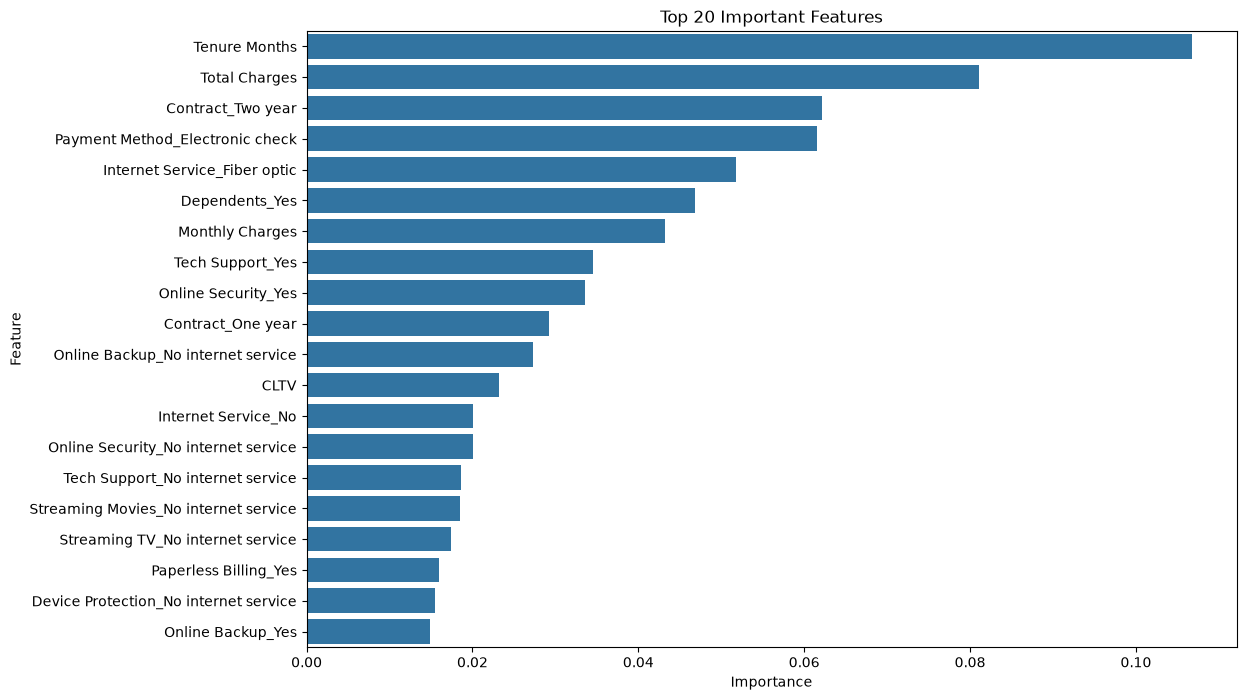



PROJECT COMPLETED SUCCESSFULLY
Best Model Saved
Scaler Saved
Feature Names Saved


In [12]:
# ==========================================================
# TELECOM CUSTOMER CHURN PREDICTION - MODEL BUILDING
# ==========================================================

# ==========================
# IMPORT LIBRARIES
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ==========================
# LOAD CLEANED DATA
# ==========================

df = pd.read_csv("../data/cleaned_data.csv")

print("="*60)
print("DATASET SHAPE")
print(df.shape)
print("="*60)

# ==========================
# FEATURES & TARGET
# ==========================

X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

# ==========================
# ONE HOT ENCODING
# ==========================

X = pd.get_dummies(X, drop_first=True)

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================
# NUMERIC COLUMNS
# ==========================

numeric_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

# ==========================================================
# HANDLE MISSING VALUES (NEW)
# ==========================================================
# Diagnose which columns / rows contain NaNs BEFORE doing
# anything else with the data.

nan_cols = X_train.columns[X_train.isnull().any()].tolist()

print("\n" + "="*60)
print("MISSING VALUE DIAGNOSTICS")
print("="*60)

print("Columns containing NaN:")
print(X_train[nan_cols].isnull().sum())

print("\nRows containing NaN (numeric columns only):")
print(X_train.loc[X_train.isnull().any(axis=1), nan_cols])

# Check whether NaNs in "Total Charges" line up with 0 tenure
# (classic Telco churn dataset issue: brand new customers have
# blank Total Charges since they haven't been billed yet)
if "Total Charges" in nan_cols:
    print("\nTenure Months for rows with missing Total Charges:")
    print(X_train.loc[X_train["Total Charges"].isnull(), "Tenure Months"])

# Impute: if Total Charges is NaN and Tenure Months == 0,
# it's a genuinely new customer -> fill with 0.
# Any remaining NaNs (in Total Charges or other numeric columns)
# get filled with the column median from X_train (fit on train only,
# then applied identically to X_test to avoid leakage).

for col in nan_cols:
    if col == "Total Charges":
        zero_tenure_mask_train = (X_train["Total Charges"].isnull()) & (X_train["Tenure Months"] == 0)
        X_train.loc[zero_tenure_mask_train, "Total Charges"] = 0

        zero_tenure_mask_test = (X_test["Total Charges"].isnull()) & (X_test["Tenure Months"] == 0)
        X_test.loc[zero_tenure_mask_test, "Total Charges"] = 0

    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

print("\nNaN values in X_train after imputation:", X_train.isnull().sum().sum())
print("NaN values in X_test after imputation:", X_test.isnull().sum().sum())

# ==========================
# SCALE NUMERICAL FEATURES
# ==========================

scaler = StandardScaler()

X_train[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

# ==========================================================
# LOGISTIC REGRESSION
# ==========================================================

print("\nTraining Logistic Regression...")

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("NaN values:", X_train.isnull().sum().sum())
print("Infinite values:", np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum())
print("Object columns:", X_train.select_dtypes(include=["object"]).columns.tolist())
print(X_train.dtypes.value_counts())

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:,1]

# ==========================================================
# DECISION TREE
# ==========================================================

print("Training Decision Tree...")

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:,1]

# ==========================================================
# RANDOM FOREST
# ==========================================================

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

# ==========================================================
# MODEL COMPARISON
# ==========================================================

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]

})

print("\n")
print("="*60)
print("MODEL COMPARISON")
print("="*60)

print(results)

# ==========================================================
# RANDOM FOREST REPORT
# ==========================================================

print("\n")
print("="*60)
print("RANDOM FOREST REPORT")
print("="*60)

print(classification_report(y_test, rf_pred))

print("Confusion Matrix")

print(confusion_matrix(y_test, rf_pred))

# ==========================================================
# CROSS VALIDATION
# ==========================================================

print("\n")
print("="*60)
print("CROSS VALIDATION")
print("="*60)

# NOTE: X and y here are the FULL (pre-imputation) dataset.
# Impute the full X the same way before cross-validating,
# otherwise this will crash with the same NaN error.

X_cv = X.copy()

for col in nan_cols:
    if col == "Total Charges":
        zero_tenure_mask = (X_cv["Total Charges"].isnull()) & (X_cv["Tenure Months"] == 0)
        X_cv.loc[zero_tenure_mask, "Total Charges"] = 0
    median_val = X_cv[col].median()
    X_cv[col] = X_cv[col].fillna(median_val)

scores = cross_val_score(
    rf_model,
    X_cv,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)

print("\nAverage ROC AUC:", scores.mean())

# ==========================================================
# HYPERPARAMETER TUNING
# ==========================================================

print("\n")
print("="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,15,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

search = RandomizedSearchCV(

    RandomForestClassifier(random_state=42),

    param_distributions=param_grid,

    n_iter=10,

    cv=5,

    scoring="roc_auc",

    random_state=42,

    n_jobs=-1

)

search.fit(X_train, y_train)

print("\nBest Parameters")

print(search.best_params_)

best_model = search.best_estimator_

best_pred = best_model.predict(X_test)

best_prob = best_model.predict_proba(X_test)[:,1]

print("\n")
print("="*60)
print("BEST MODEL REPORT")
print("="*60)

print(classification_report(y_test, best_pred))

print("ROC AUC :", roc_auc_score(y_test, best_prob))

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

# ==========================================================
# SAVE MODEL
# ==========================================================

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/churn_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "../models/feature_names.pkl"
)

print("\n")
print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

print("Best Model Saved")

print("Scaler Saved")

print("Feature Names Saved")

MODEL PERFORMANCE
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2        Random Forest  0.806246   0.674740  0.521390  0.588235  0.844658
0  Logistic Regression  0.793471   0.625378  0.553476  0.587234  0.840998
1        Decision Tree  0.753726   0.536388  0.532086  0.534228  0.682951


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.55      0.59       374

    accuracy                           0.79      1409
   macro avg       0.74      0.72      0.72      1409
weighted avg       0.79      0.79      0.79      1409



DECISION TREE
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1035
           1       0.54      0.53      0.53       374

    accuracy                           0.75      1409
   macro avg       0.68      0.68      0.68      1409
weighted avg       0.75      0.75      0.75      

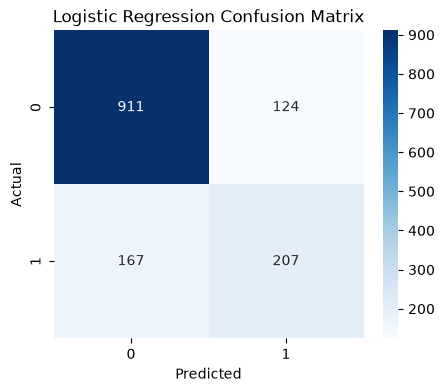

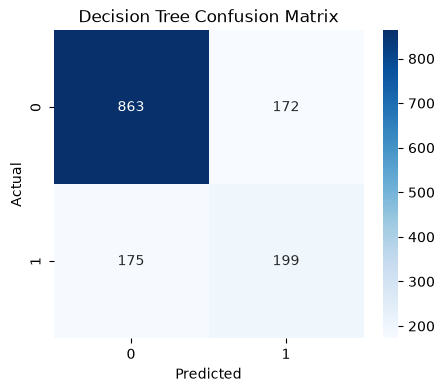

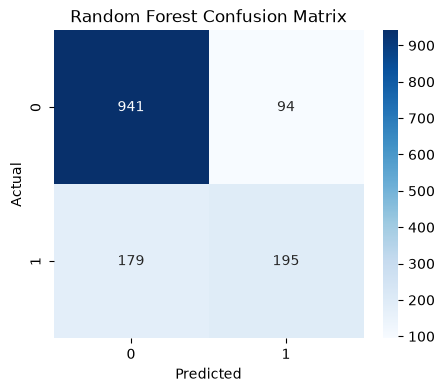



RANDOM FOREST CROSS VALIDATION
Cross Validation Scores:
[0.8495957  0.86287298 0.83325971 0.84305537 0.8501457 ]

Average ROC AUC:
0.8477858914010798


BEST PERFORMING MODEL
Random Forest

Evaluation Completed Successfully.


In [14]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import cross_val_score

# ==========================================================
# MODEL COMPARISON
# ==========================================================

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]

})

results = results.sort_values(
    by="ROC AUC",
    ascending=False
)

print("="*70)
print("MODEL PERFORMANCE")
print("="*70)

print(results)

# ==========================================================
# CLASSIFICATION REPORTS
# ==========================================================

models = {

    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred

}

for model_name, prediction in models.items():

    print("\n")
    print("="*70)
    print(model_name.upper())
    print("="*70)

    print(classification_report(
        y_test,
        prediction
    ))

# ==========================================================
# CONFUSION MATRICES
# ==========================================================

for model_name, prediction in models.items():

    cm = confusion_matrix(y_test, prediction)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{model_name} Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

# ==========================================================
# CROSS VALIDATION
# ==========================================================

print("\n")
print("="*70)
print("RANDOM FOREST CROSS VALIDATION")
print("="*70)

scores = cross_val_score(

    rf_model,

    X,

    y,

    cv=5,

    scoring="roc_auc",

    n_jobs=-1

)

print("Cross Validation Scores:")

print(scores)

print("\nAverage ROC AUC:")

print(scores.mean())

# ==========================================================
# BEST MODEL
# ==========================================================

best_model_name = results.iloc[0]["Model"]

print("\n")
print("="*70)
print("BEST PERFORMING MODEL")
print("="*70)

print(best_model_name)

print("\nEvaluation Completed Successfully.")

HYPERPARAMETER TUNING
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

Best Cross Validation ROC AUC:
0.8530403779694609


BEST MODEL PERFORMANCE
Accuracy : 0.8062455642299503
Precision: 0.7130801687763713
Recall   : 0.45187165775401067
F1 Score : 0.5531914893617021
ROC AUC  : 0.8486204758583274

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1035
           1       0.71      0.45      0.55       374

    accuracy                           0.81      1409
   macro avg       0.77      0.69      0.71      1409
weighted avg       0.80      0.81      0.79      1409



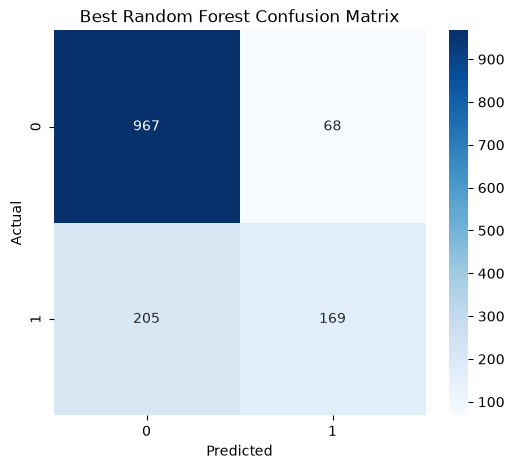


Top 20 Important Features

                                     Feature  Importance
0                              Tenure Months    0.103913
2                              Total Charges    0.077493
1154                       Contract_Two year    0.055069
1                            Monthly Charges    0.049538
1157         Payment Method_Electronic check    0.047521
1135                          Dependents_Yes    0.045706
1139            Internet Service_Fiber optic    0.043720
3                                       CLTV    0.033697
1142                     Online Security_Yes    0.030977
1153                       Contract_One year    0.028002
1148                        Tech Support_Yes    0.027000
1143       Online Backup_No internet service    0.023403
1155                   Paperless Billing_Yes    0.021103
1141     Online Security_No internet service    0.017346
1151    Streaming Movies_No internet service    0.016841
1140                     Internet Service_No    0.016405
114

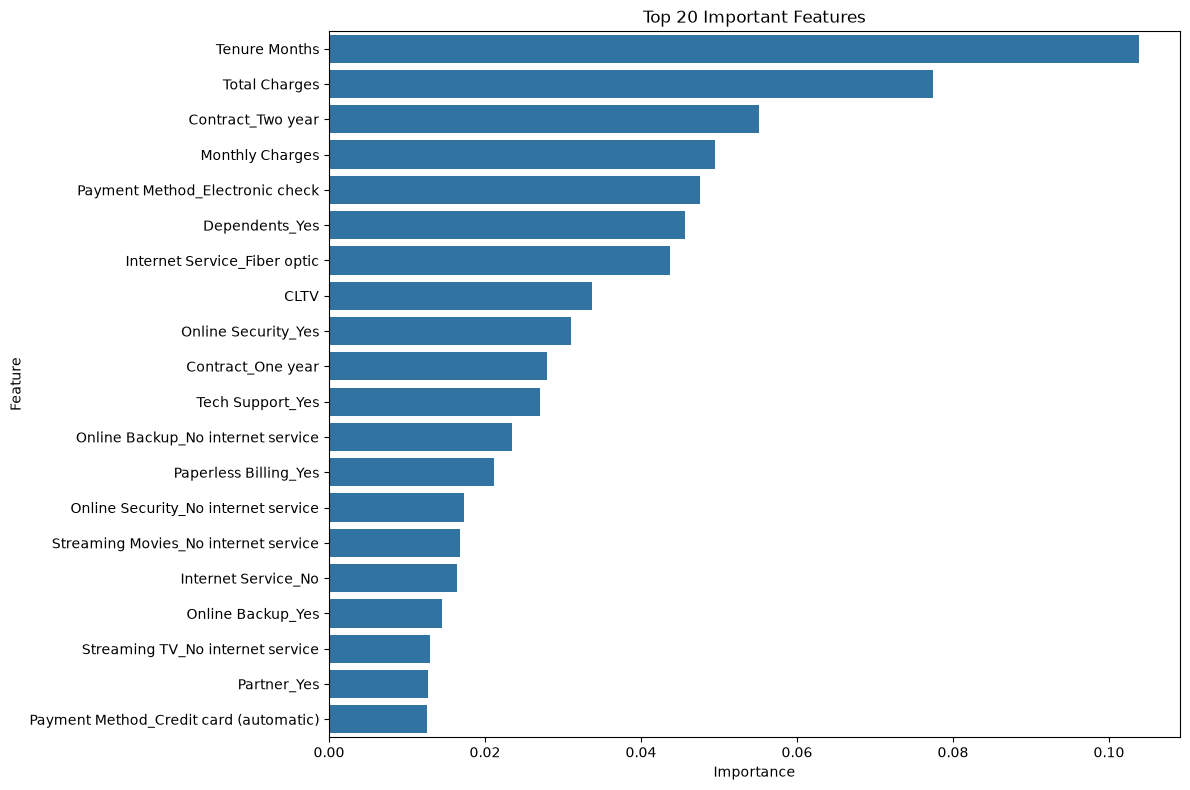



PROJECT COMPLETED SUCCESSFULLY
✅ Best Model Saved
✅ Scaler Saved
✅ Feature Names Saved


In [15]:
# ==========================================================
# HYPERPARAMETER TUNING + BEST MODEL EVALUATION + SAVE MODEL
# ==========================================================

import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# ==========================================================
# PARAMETER GRID
# ==========================================================

param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [5, 10, 15, 20, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]

}

# ==========================================================
# RANDOMIZED SEARCH
# ==========================================================

random_search = RandomizedSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_distributions=param_grid,

    n_iter=20,

    scoring="roc_auc",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation ROC AUC:")
print(random_search.best_score_)

# ==========================================================
# BEST MODEL PREDICTION
# ==========================================================

best_pred = best_model.predict(X_test)

best_prob = best_model.predict_proba(X_test)[:,1]

# ==========================================================
# MODEL PERFORMANCE
# ==========================================================

print("\n")
print("="*70)
print("BEST MODEL PERFORMANCE")
print("="*70)

print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall   :", recall_score(y_test, best_pred))
print("F1 Score :", f1_score(y_test, best_pred))
print("ROC AUC  :", roc_auc_score(y_test, best_prob))

print("\nClassification Report\n")

print(classification_report(y_test, best_pred))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Best Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Important Features\n")

print(importance.head(20))

plt.figure(figsize=(12,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.show()

# ==========================================================
# SAVE MODEL
# ==========================================================

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/churn_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "../models/feature_names.pkl"
)

print("\n")
print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

print("Best Model Saved")

print("Scaler Saved")

print("Feature Names Saved")